# Parent Fault Demo

This notebook demonstrates the basic usage of `parserf` for exploring parent fault data from earthquake rupture forecast models.

Topics covered:

1. Loading a `FaultModelDataset`
    - Browsing available parent faults
2. Finding the `parent_id` from a parent fault name
3. Creating `ParentFault` instances
    - Accessing `ParentFaultData` properties (subsection table with dip, depth, dimensions, etc.)
    - Faulting style information (dominant style and style breakdown)
    - Exploring `ParentFaultRuptures` (cumulative MFDs for all child subsections)
4. Using `ParentFaultData` and `ParentFaultRuptures` directly

## Imports

In [55]:
import matplotlib.pyplot as plt

from parserf.models import FaultModel, FaultModelDataset
from parserf.parent import ParentFault, ParentFaultData, ParentFaultRuptures

## 1. Loading a FaultModelDataset

`FaultModelDataset` is the entry point for all data access. It wraps a specific earthquake rupture forecast dataset and provides cached access to fault sections, parent IDs, and rupture scenarios.

Available fault models:
- `FaultModel.UCERF3_31` — UCERF3 fault model 3.1
- `FaultModel.UCERF3_32` — UCERF3 fault model 3.2
- `FaultModel.NSHMP_2023` — USGS NSHM CONUS v6.0.0

In [56]:
# Load the UCERF3 fault model 3.1 dataset
dataset = FaultModelDataset(FaultModel.NSHMP_2023)
print("Dataset loaded:", dataset)

Dataset loaded: FaultModelDataset(model=<FaultModel.NSHMP_2023: 2023>)


### Browsing available parent faults

The `parent_ids` table lists all parent fault names and their integer IDs.

In [57]:
print("Number of parent faults:", len(dataset.parent_ids))
dataset.parent_ids.head(10)

Number of parent faults: 1016


,parent_id,parent_name
0,2503,Abert Rim
1,2600,Acala
2,1138,Agai Pah Hills
3,1,Airport Lake
4,310,Airport Lake (south)
5,2400,Alamogordo
6,2000,Algodones
7,2,Almanor
8,2504,Alvin Canyon
9,2601,Amargosa


## 2. Finding the Parent ID from a Parent Fault Name

Use `dataset.get_parent_id()` to resolve a parent fault name to its integer ID. This is analogous to `dataset.nearest_index()` for subsections.

In [58]:
parent_id = dataset.get_parent_id(name="Little Lake")
print("Parent ID for 'Little Lake':", parent_id)

Parent ID for 'Little Lake': 145


## 3. Creating a ParentFault Instance

`ParentFault` is a thin facade over a parent fault and its child subsections. It validates the name and then exposes two sub-objects:
- `.data` — subsection attributes (name, geometry, depths, dip, dimensions, etc.)
- `.ruptures` — cumulative magnitude frequency distributions for each child subsection

In [59]:
flt = ParentFault(dataset, name="Little Lake")
print(flt)

ParentFault(fault_model=NSHMP_2023, name='Little Lake', parent_id=145)


### Accessing ParentFaultData Properties

`flt.data` is a `ParentFaultData` object with properties for the parent fault's identity and a table of all child subsection attributes.

In [60]:
# Basic identification
print("Name:       ", flt.data.name)
print("Parent ID:  ", flt.data.parent_id)
print("Fault Model:", flt.data.fault_model)

Name:        Little Lake
Parent ID:   145
Fault Model: 2023


In [61]:
# Subsection attributes table
subs = flt.data.subsections
print(f"Number of subsections: {len(subs)}")
print(f"Columns: {list(subs.columns)}")
subs

Number of subsections: 7
Columns: ['name', 'dip', 'dip_direction', 'upper_depth_km', 'lower_depth_km', 'aseismicity', 'length_km', 'width_km', 'area_km2', 'geometry']


,name,dip,dip_direction,upper_depth_km,lower_depth_km,aseismicity,length_km,width_km,area_km2,geometry
index,,,,,,,,,,
2445,Little Lake (0),90.0,57.0,0.0,13.0,0.1,6.244454,13.0,81.177907,"LINESTRING (-117.64749 35.60516, -117.68458 35..."
2446,Little Lake (1),90.0,57.0,0.0,13.0,0.1,6.244922,13.0,81.183983,"LINESTRING (-117.68458 35.6526, -117.72172 35...."
2447,Little Lake (2),90.0,57.0,0.0,13.0,0.1,6.244452,13.0,81.177874,"LINESTRING (-117.72172 35.70003, -117.72816 35..."
2448,Little Lake (3),90.0,57.0,0.0,13.0,0.1,6.245402,13.0,81.190223,"LINESTRING (-117.75891 35.74744, -117.79616 35..."
2449,Little Lake (4),90.0,57.0,0.0,13.0,0.1,6.244019,13.0,81.172251,"LINESTRING (-117.79616 35.79484, -117.80907 35..."
2450,Little Lake (5),90.0,57.0,0.0,13.0,0.1,6.245198,13.0,81.187572,"LINESTRING (-117.83321 35.84234, -117.87019 35..."
2451,Little Lake (6),90.0,57.0,0.0,13.0,0.1,6.247347,13.0,81.215515,"LINESTRING (-117.87019 35.8899, -117.88341 35...."


In [62]:
# Summary statistics for dimensions
subs[["dip", "upper_depth_km", "lower_depth_km", "length_km", "width_km", "area_km2"]].describe()

,dip,upper_depth_km,lower_depth_km,length_km,width_km,area_km2
count,7.0,7.0,7.0,7.000000,7.0,7.000000
mean,90.0,0.0,13.0,6.245113,13.0,81.186475
std,0.0,0.0,0.0,0.001094,0.0,0.014227
min,90.0,0.0,13.0,6.244019,13.0,81.172251
25%,90.0,0.0,13.0,6.244453,13.0,81.177890
50%,90.0,0.0,13.0,6.244922,13.0,81.183983
75%,90.0,0.0,13.0,6.245300,13.0,81.188897
max,90.0,0.0,13.0,6.247347,13.0,81.215515


In [63]:
# Dominant faulting style
print("Dominant style:", flt.data.style)

# Full style breakdown
flt.data.style_counts

Dominant style: normal oblique


,style,count
0,normal oblique,3583
1,normal,3327
2,strike-slip,465
3,reverse oblique,199


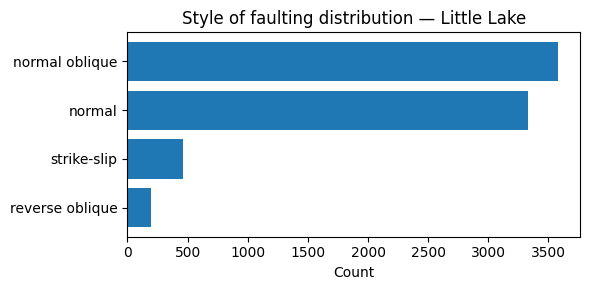

In [64]:
# Bar chart of style counts
sc = flt.data.style_counts
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(sc["style"], sc["count"])
ax.set_xlabel("Count")
ax.set_title(f"Style of faulting distribution — {flt.data.name}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

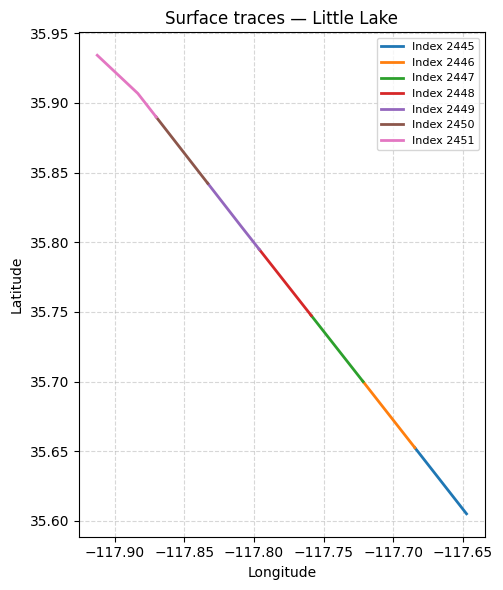

In [65]:
# Plot subsection surface traces
fig, ax = plt.subplots(figsize=(8, 6))
for idx, row in subs.iterrows():
    xs, ys = row["geometry"].xy
    ax.plot(xs, ys, linewidth=2, label=f"Index {idx}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Surface traces — {flt.data.name}")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Exploring ParentFaultRuptures

`flt.ruptures` is a `ParentFaultRuptures` object providing:
- `cumulative_mfds` — a DataFrame of cumulative magnitude frequency distributions for each child subsection, with columns `index`, `magnitude`, and `cumulative_rate`

In [66]:
mfds = flt.ruptures.cumulative_mfds
print(f"Total rows: {len(mfds)}")
print(f"Subsection indices: {sorted(mfds['index'].unique())}")
print(f"Columns: {list(mfds.columns)}")
print(mfds.head(5))
print(mfds.tail(5))

Total rows: 810
Subsection indices: [np.int64(2445), np.int64(2446), np.int64(2447), np.int64(2448), np.int64(2449), np.int64(2450), np.int64(2451)]
Columns: ['index', 'magnitude', 'cumulative_rate']
   index  magnitude  cumulative_rate
0   2445       6.29         0.000364
1   2445       6.48         0.000353
2   2445       6.62         0.000345
3   2445       6.63         0.000340
4   2445       6.72         0.000339
     index  magnitude  cumulative_rate
805   2451       8.01     7.037767e-07
806   2451       8.03     6.871176e-07
807   2451       8.05     6.755358e-07
808   2451       8.07     6.646595e-07
809   2451       8.10     6.512668e-07


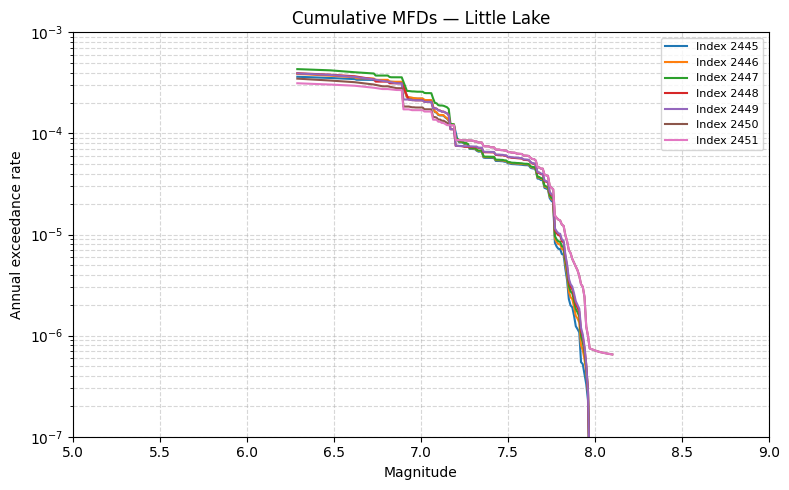

In [67]:
# Plot cumulative MFD for each subsection
fig, ax = plt.subplots(figsize=(8, 5))
for idx, group in mfds.groupby("index"):
    ax.semilogy(group["magnitude"], group["cumulative_rate"], linewidth=1.5, label=f"Index {idx}")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Annual exceedance rate")
ax.set_title(f"Cumulative MFDs — {flt.data.name}")
ax.set(xlim=(5, 9), ylim=(1e-7, 1e-3))
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Using ParentFaultData and ParentFaultRuptures Directly

You can also instantiate `ParentFaultData` and `ParentFaultRuptures` directly without going through `ParentFault`. These classes take `parent_id` (an integer) rather than `name`.

In [68]:
# Direct instantiation of ParentFaultData
parent_id = dataset.get_parent_id(name="Little Lake")
data = ParentFaultData(dataset, parent_id=parent_id)
print("Name:", data.name)
print("Parent ID:", data.parent_id)
print("Number of subsections:", len(data.subsections))

Name: Little Lake
Parent ID: 145
Number of subsections: 7


In [69]:
# Direct instantiation of ParentFaultRuptures
ruptures = ParentFaultRuptures(dataset, parent_id=parent_id)
print("Cumulative MFD rows:", len(ruptures.cumulative_mfds))

Cumulative MFD rows: 810
